In [1]:


from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CICIDS2017_ETL") \
    .master("local[4]") \
    .config("spark.driver.memory", "10g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.default.parallelism", "6") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")



Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/09 13:51:49 WARN Utils: Your hostname, aswin-Inspiron, resolves to a loopback address: 127.0.1.1; using 192.168.26.189 instead (on interface wlp1s0)
26/03/09 13:51:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 13:51:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:

df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("dataset/*.csv")

26/03/09 12:52:00 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: dataset/*.csv.
java.io.FileNotFoundException: File dataset/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource$$

In [ ]:
df.printSchema()


root
 |--  Destination Port: integer (nullable = true)
 |--  Flow Duration: integer (nullable = true)
 |--  Total Fwd Packets: integer (nullable = true)
 |--  Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |--  Total Length of Bwd Packets: integer (nullable = true)
 |--  Fwd Packet Length Max: integer (nullable = true)
 |--  Fwd Packet Length Min: integer (nullable = true)
 |--  Fwd Packet Length Mean: double (nullable = true)
 |--  Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |--  Bwd Packet Length Min: integer (nullable = true)
 |--  Bwd Packet Length Mean: double (nullable = true)
 |--  Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |--  Flow Packets/s: double (nullable = true)
 |--  Flow IAT Mean: double (nullable = true)
 |--  Flow IAT Std: double (nullable = true)
 |--  Flow IAT Max: integer (nullable = true)
 |-- 

In [2]:
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType, LongType, StringType

schema = StructType([
    StructField("Destination Port", IntegerType(), True),
    StructField("Flow Duration", IntegerType(), True),
    StructField("Total Fwd Packets", IntegerType(), True),
    StructField("Total Backward Packets", IntegerType(), True),
    StructField("Total Length of Fwd Packets", IntegerType(), True),
    StructField("Total Length of Bwd Packets", IntegerType(), True),
    StructField("Fwd Packet Length Max", IntegerType(), True),
    StructField("Fwd Packet Length Min", IntegerType(), True),
    StructField("Fwd Packet Length Mean", DoubleType(), True),
    StructField("Fwd Packet Length Std", DoubleType(), True),
    StructField("Bwd Packet Length Max", IntegerType(), True),
    StructField("Bwd Packet Length Min", IntegerType(), True),
    StructField("Bwd Packet Length Mean", DoubleType(), True),
    StructField("Bwd Packet Length Std", DoubleType(), True),
    StructField("Flow Bytes/s", DoubleType(), True),
    StructField("Flow Packets/s", DoubleType(), True),
    StructField("Flow IAT Mean", DoubleType(), True),
    StructField("Flow IAT Std", DoubleType(), True),
    StructField("Flow IAT Max", IntegerType(), True),
    StructField("Flow IAT Min", IntegerType(), True),
    StructField("Fwd IAT Total", IntegerType(), True),
    StructField("Fwd IAT Mean", DoubleType(), True),
    StructField("Fwd IAT Std", DoubleType(), True),
    StructField("Fwd IAT Max", IntegerType(), True),
    StructField("Fwd IAT Min", IntegerType(), True),
    StructField("Bwd IAT Total", IntegerType(), True),
    StructField("Bwd IAT Mean", DoubleType(), True),
    StructField("Bwd IAT Std", DoubleType(), True),
    StructField("Bwd IAT Max", IntegerType(), True),
    StructField("Bwd IAT Min", IntegerType(), True),
    StructField("Fwd PSH Flags", IntegerType(), True),
    StructField("Bwd PSH Flags", IntegerType(), True),
    StructField("Fwd URG Flags", IntegerType(), True),
    StructField("Bwd URG Flags", IntegerType(), True),
    StructField("Fwd Header Length", LongType(), True),    # your schema shows 'long'
    StructField("Bwd Header Length", IntegerType(), True),
    StructField("Fwd Packets/s", DoubleType(), True),
    StructField("Bwd Packets/s", DoubleType(), True),
    StructField("Min Packet Length", IntegerType(), True),
    StructField("Max Packet Length", IntegerType(), True),
    StructField("Packet Length Mean", DoubleType(), True),
    StructField("Packet Length Std", DoubleType(), True),
    StructField("Packet Length Variance", DoubleType(), True),
    StructField("FIN Flag Count", IntegerType(), True),
    StructField("SYN Flag Count", IntegerType(), True),
    StructField("RST Flag Count", IntegerType(), True),
    StructField("PSH Flag Count", IntegerType(), True),
    StructField("ACK Flag Count", IntegerType(), True),
    StructField("URG Flag Count", IntegerType(), True),
    StructField("CWE Flag Count", IntegerType(), True),
    StructField("ECE Flag Count", IntegerType(), True),
    StructField("Down/Up Ratio", IntegerType(), True),
    StructField("Average Packet Size", DoubleType(), True),
    StructField("Avg Fwd Segment Size", DoubleType(), True),
    StructField("Avg Bwd Segment Size", DoubleType(), True),
    StructField("Fwd Header Length.1", LongType(), True),  # the duplicate col (index 55)
    StructField("Fwd Avg Bytes/Bulk", IntegerType(), True),
    StructField("Fwd Avg Packets/Bulk", IntegerType(), True),
    StructField("Fwd Avg Bulk Rate", IntegerType(), True),
    StructField("Bwd Avg Bytes/Bulk", IntegerType(), True),
    StructField("Bwd Avg Packets/Bulk", IntegerType(), True),
    StructField("Bwd Avg Bulk Rate", IntegerType(), True),
    StructField("Subflow Fwd Packets", IntegerType(), True),
    StructField("Subflow Fwd Bytes", IntegerType(), True),
    StructField("Subflow Bwd Packets", IntegerType(), True),
    StructField("Subflow Bwd Bytes", IntegerType(), True),
    StructField("Init_Win_bytes_forward", IntegerType(), True),
    StructField("Init_Win_bytes_backward", IntegerType(), True),
    StructField("act_data_pkt_fwd", IntegerType(), True),
    StructField("min_seg_size_forward", IntegerType(), True),
    StructField("Active Mean", DoubleType(), True),
    StructField("Active Std", DoubleType(), True),
    StructField("Active Max", IntegerType(), True),
    StructField("Active Min", IntegerType(), True),
    StructField("Idle Mean", DoubleType(), True),
    StructField("Idle Std", DoubleType(), True),
    StructField("Idle Max", IntegerType(), True),
    StructField("Idle Min", IntegerType(), True),
    StructField("Label", StringType(), True),
])

In [3]:
df = spark.read \
    .option("header", "true") \
    .option("mode", "DROPMALFORMED") \
    .schema(schema) \
    .csv("dataset/*.csv")



    

26/03/09 13:52:16 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: dataset/*.csv.
java.io.FileNotFoundException: File dataset/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource$$

# Transform Phase

In [ ]:
df = df.toDF(*[c.strip() for c in df.columns])
df = df.withColumnRenamed("Fwd Header Length.1", "Fwd Header Length2")

### Handle missing values

In [5]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, FloatType

# Count nulls
null_counts = df.select([
    F.count(F.when(F.col(c).isNull() | F.isnan(c), c)).alias(c)
    for c in df.columns
    if df.schema[c].dataType in [FloatType(), DoubleType()]
])

In [6]:
null_counts.show()


26/03/09 13:52:30 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Fwd Packet Length Mean,  Fwd Packet Length Std,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Fwd IAT Mean,  Fwd IAT Std,  Bwd IAT Mean,  Bwd IAT Std, Fwd Packets/s,  Bwd Packets/s,  Packet Length Mean,  Packet Length Std,  Packet Length Variance,  Average Packet Size,  Avg Fwd Segment Size,  Avg Bwd Segment Size, Active Mean,  Active Std, Idle Mean,  Idle Std
 Schema: Fwd Packet Length Mean, Fwd Packet Length Std, Bwd Packet Length Mean, Bwd Packet Length Std, Flow Bytes/s, Flow Packets/s, Flow IAT Mean, Flow IAT Std, Fwd IAT Mean, Fwd IAT Std, Bwd IAT Mean, Bwd IAT Std, Fwd Packets/s, Bwd Packets/s, Packet Length Mean, Packet Length Std, Packet Length Variance, Average Packet Size, Avg Fwd Segment Size, Avg Bwd Segment Size, Active Mean, Active Std, Idle Mean, Idle Std
Expected: Fwd Packet Length Mean but found:  Fwd Packet Le

+----------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+-----------+------------+-----------+-------------+-------------+------------------+-----------------+----------------------+-------------------+--------------------+--------------------+-----------+----------+---------+--------+
|Fwd Packet Length Mean|Fwd Packet Length Std|Bwd Packet Length Mean|Bwd Packet Length Std|Flow Bytes/s|Flow Packets/s|Flow IAT Mean|Flow IAT Std|Fwd IAT Mean|Fwd IAT Std|Bwd IAT Mean|Bwd IAT Std|Fwd Packets/s|Bwd Packets/s|Packet Length Mean|Packet Length Std|Packet Length Variance|Average Packet Size|Avg Fwd Segment Size|Avg Bwd Segment Size|Active Mean|Active Std|Idle Mean|Idle Std|
+----------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+-----------+------------+-----------+-------------+------------

In [7]:
from pyspark.sql.functions import col, when, isnan, count

# ── 1. Replace Infinity values first ──────────────────────────────
inf_cols = ["Flow Bytes/s", "Flow Packets/s"]

for c in inf_cols:
    df = df.withColumn(c,
        when(col(c) == float("inf"),  None)
       .when(col(c) == float("-inf"), None)
       .otherwise(col(c))
    )

In [8]:
# Fill nulls  with 0 
df = df.fillna(0, subset=["Flow Bytes/s", "Flow Packets/s"])


In [9]:
df.count()

2830743

In [10]:
# ── 3. Verify no nulls remain ──────────────────────────────────────
double_cols = [f.name for f in df.schema.fields
               if str(f.dataType) in ["DoubleType()", "FloatType()"]]

df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in double_cols
]).show()

26/03/09 13:52:59 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Fwd Packet Length Mean,  Fwd Packet Length Std,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Fwd IAT Mean,  Fwd IAT Std,  Bwd IAT Mean,  Bwd IAT Std, Fwd Packets/s,  Bwd Packets/s,  Packet Length Mean,  Packet Length Std,  Packet Length Variance,  Average Packet Size,  Avg Fwd Segment Size,  Avg Bwd Segment Size, Active Mean,  Active Std, Idle Mean,  Idle Std
 Schema: Fwd Packet Length Mean, Fwd Packet Length Std, Bwd Packet Length Mean, Bwd Packet Length Std, Flow Bytes/s, Flow Packets/s, Flow IAT Mean, Flow IAT Std, Fwd IAT Mean, Fwd IAT Std, Bwd IAT Mean, Bwd IAT Std, Fwd Packets/s, Bwd Packets/s, Packet Length Mean, Packet Length Std, Packet Length Variance, Average Packet Size, Avg Fwd Segment Size, Avg Bwd Segment Size, Active Mean, Active Std, Idle Mean, Idle Std
Expected: Fwd Packet Length Mean but found:  Fwd Packet Le

+----------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+-----------+------------+-----------+-------------+-------------+------------------+-----------------+----------------------+-------------------+--------------------+--------------------+-----------+----------+---------+--------+
|Fwd Packet Length Mean|Fwd Packet Length Std|Bwd Packet Length Mean|Bwd Packet Length Std|Flow Bytes/s|Flow Packets/s|Flow IAT Mean|Flow IAT Std|Fwd IAT Mean|Fwd IAT Std|Bwd IAT Mean|Bwd IAT Std|Fwd Packets/s|Bwd Packets/s|Packet Length Mean|Packet Length Std|Packet Length Variance|Average Packet Size|Avg Fwd Segment Size|Avg Bwd Segment Size|Active Mean|Active Std|Idle Mean|Idle Std|
+----------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+-----------+------------+-----------+-------------+------------

### Remove Duplicates

In [11]:
#Check duplicate count 
total = df.count()
distinct = df.dropDuplicates().count()
print(f"Total rows      : {total:,}")
print(f"Distinct rows   : {distinct:,}")
print(f"Duplicates found: {total - distinct:,}")

26/03/09 13:53:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/09 13:53:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Leng

Total rows      : 2,830,743
Distinct rows   : 2,522,362
Duplicates found: 308,381


In [12]:
# ── 2. Drop duplicates based on flow identity columns ─────────────
df = df.dropDuplicates()

print(f"Rows after dedup: {df.count():,}")

26/03/09 13:54:34 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

Rows after dedup: 2,522,362


In [13]:
# ── 3. Verify ──────────────────────────────────────────────────────
print(f"Duplicates remaining: {df.count() - df.dropDuplicates().count():,}")

26/03/09 13:55:34 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

Duplicates remaining: 0


In [14]:
df.groupBy("Label") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(20, truncate=False)

26/03/09 13:57:37 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

+--------------------------+-------+
|Label                     |count  |
+--------------------------+-------+
|BENIGN                    |2096484|
|DoS Hulk                  |172849 |
|DDoS                      |128016 |
|PortScan                  |90819  |
|DoS GoldenEye             |10286  |
|FTP-Patator               |5933   |
|DoS slowloris             |5385   |
|DoS Slowhttptest          |5228   |
|SSH-Patator               |3219   |
|Bot                       |1953   |
|Web Attack � Brute Force  |1470   |
|Web Attack � XSS          |652    |
|Infiltration              |36     |
|Web Attack � Sql Injection|21     |
|Heartbleed                |11     |
+--------------------------+-------+



In [ ]:

# Verify
print([c for c in df.columns if "Header" in c])
# Should show: ['Fwd Header Length', 'Bwd Header Length', 'Fwd Header Length2']

exclude_cols = [
    "Label",
    "label_index",
    "is_attack",
    "source_file",
    "duration_bucket"
]

# Only include numeric columns
from pyspark.sql.types import NumericType

feature_cols = [
    f.name for f in df.schema.fields
    if isinstance(f.dataType, NumericType)
    and f.name not in exclude_cols
]

# ── STEP 1: Rename the problematic duplicate column ──────────────


['Fwd Header Length', 'Bwd Header Length', 'Fwd Header Length2']


26/03/09 14:01:16 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

Sample size: 125,748 rows


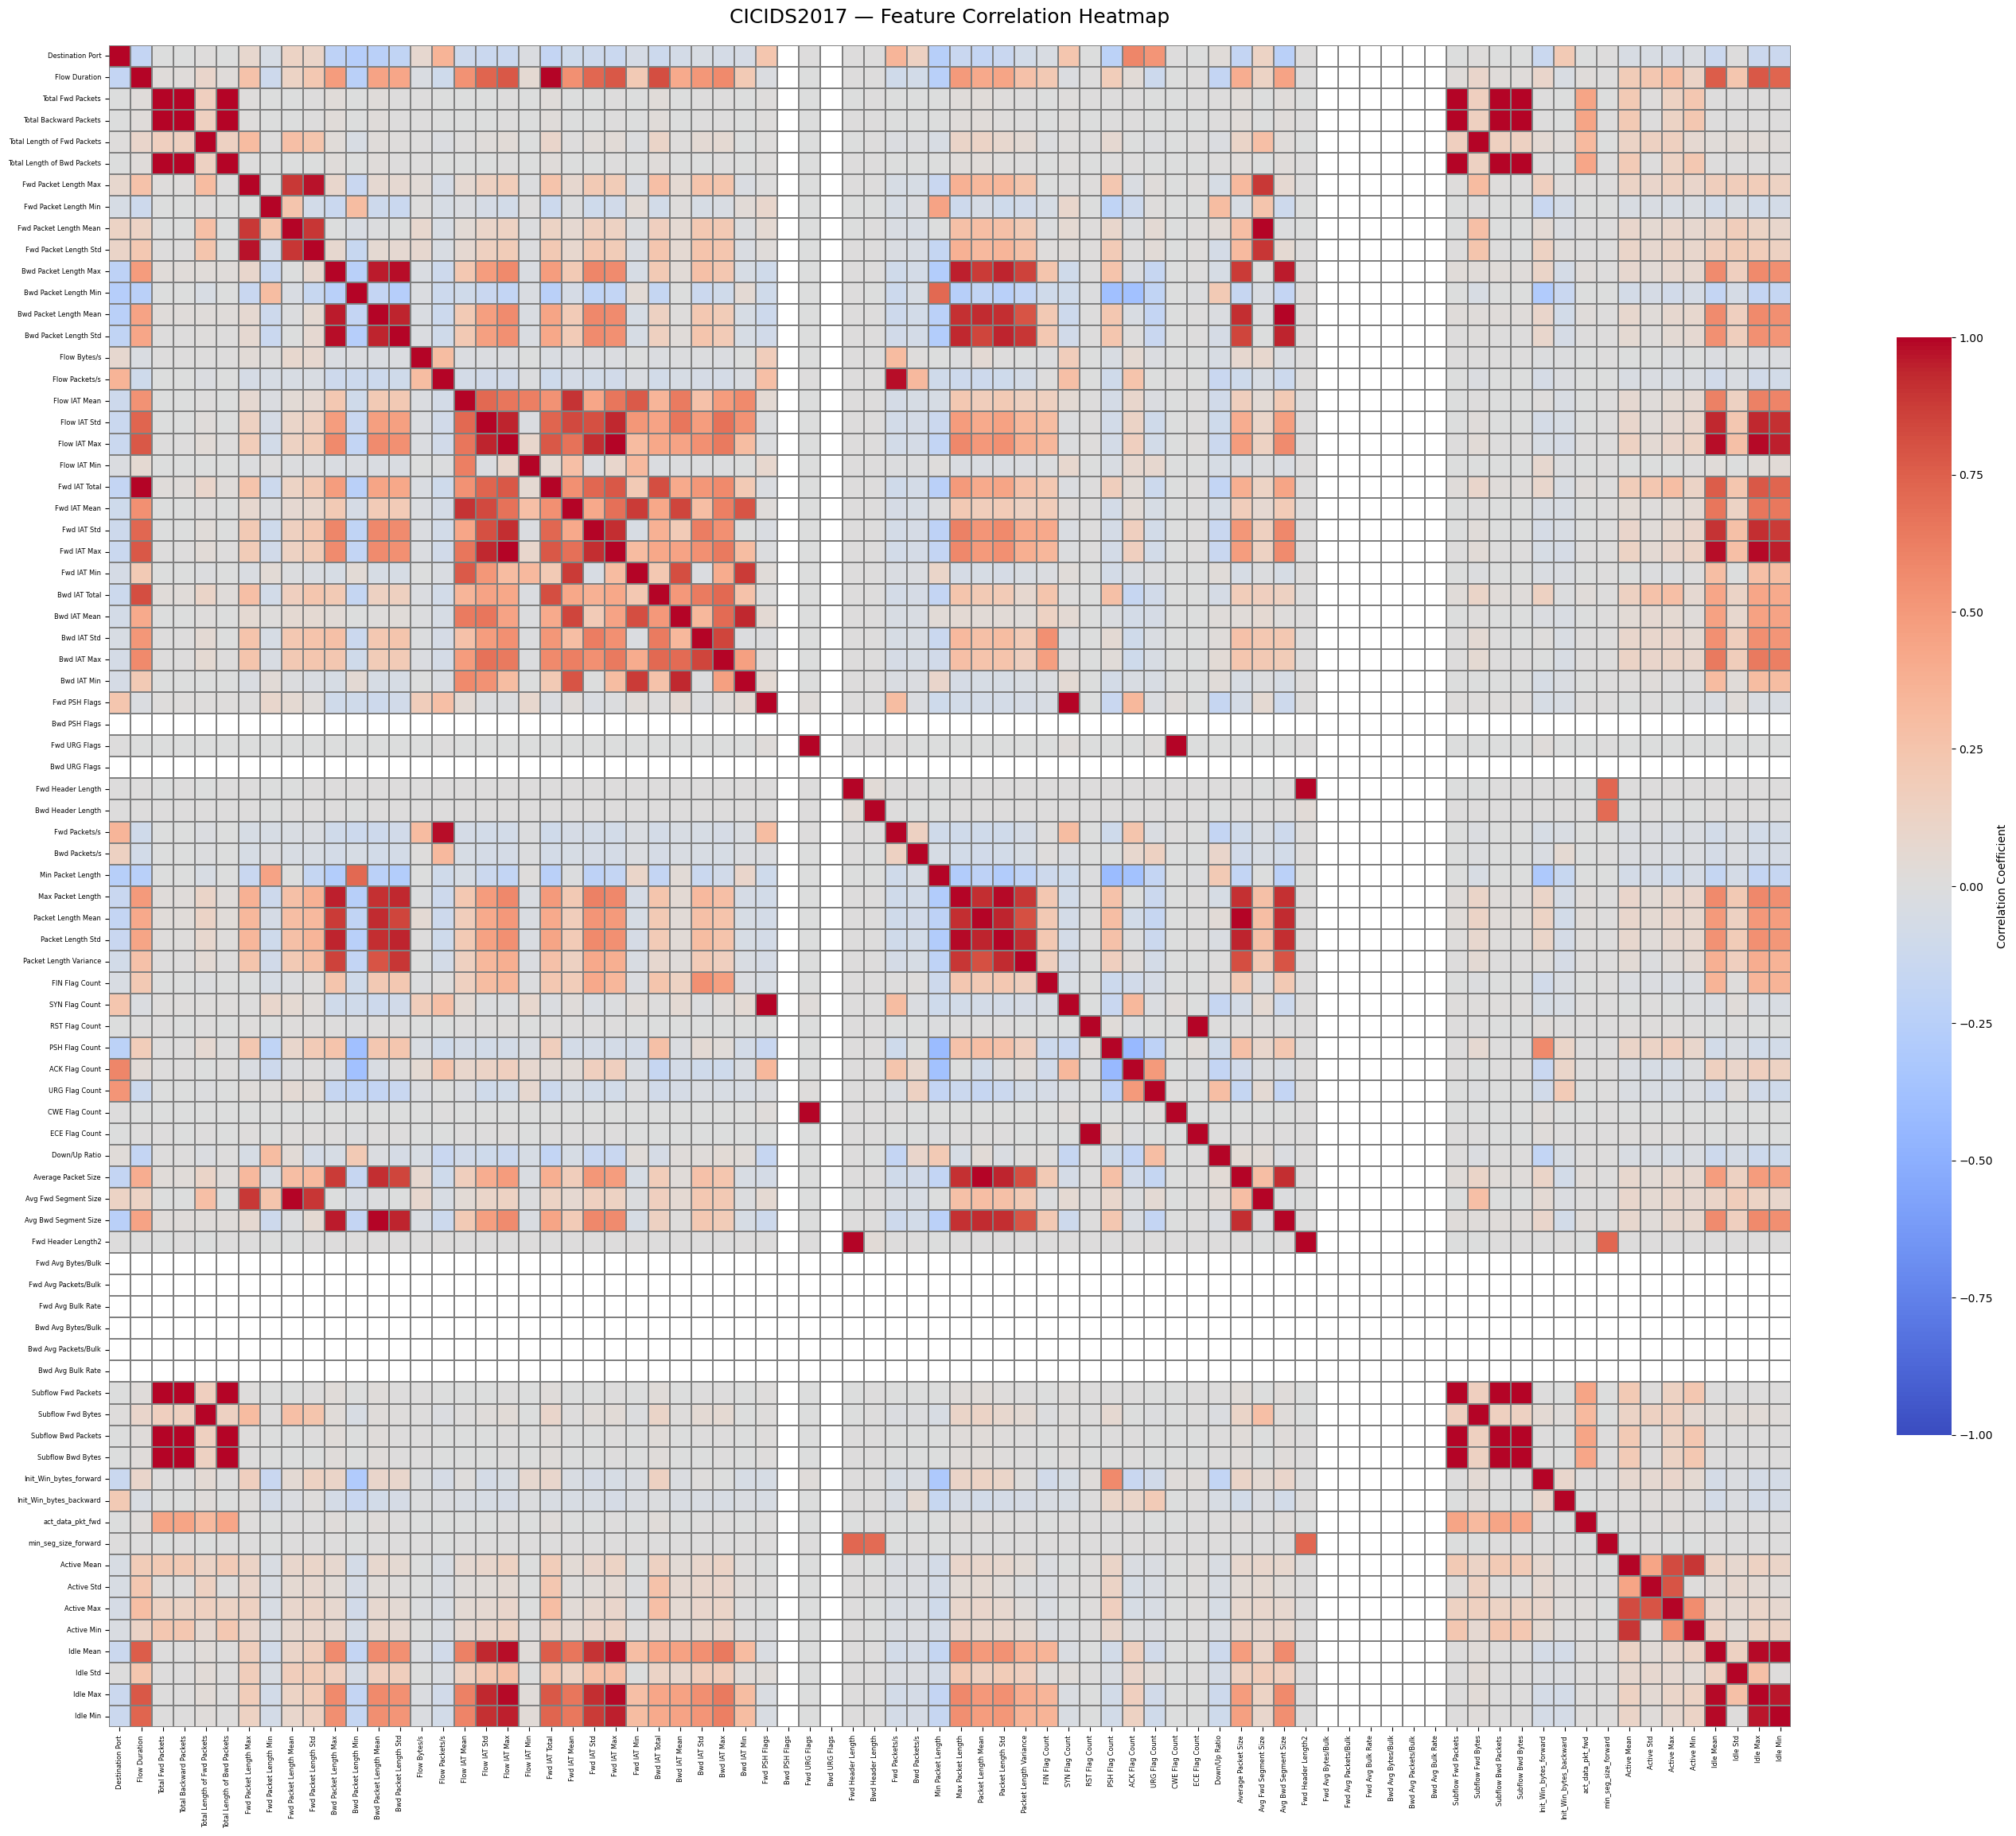

Saved: correlation_heatmap.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── STEP 1: Sample data (can't plot 2.8M rows) ───────────────────
sample_df = df.select(feature_cols).sample(fraction=0.05, seed=42)
pdf = sample_df.toPandas()

print(f"Sample size: {len(pdf):,} rows")

# ── STEP 2: Compute correlation matrix ───────────────────────────
corr_matrix = pdf.corr()

# ── STEP 3: Plot heatmap ──────────────────────────────────────────
plt.figure(figsize=(28, 24))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",       # blue=negative, red=positive correlation
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.1,
    linecolor="gray",
    annot=False,           # too many cols for numbers — keep clean
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"shrink": 0.6, "label": "Correlation Coefficient"}
)

plt.title("CICIDS2017 — Feature Correlation Heatmap", fontsize=18, pad=20)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: correlation_heatmap.png")

#### Outlier capping (IQR method)

In [ ]:
from pyspark.sql.functions import percentile_approx

q1, q3 = df.select(
    percentile_approx("Flow Duration", 0.25),
    percentile_approx("Flow Duration", 0.75)
).first()

iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df = df.withColumn("Flow Duration",
    when(col("Flow Duration") < lower, lower)
    .when(col("Flow Duration") > upper, upper)
    .otherwise(col("Flow Duration"))
)

26/03/09 13:06:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

#### Label encoding

In [ ]:
from pyspark.sql.functions import trim
from pyspark.ml.feature import StringIndexer

df = df.withColumn("Label", trim(col("Label")))

# Binary: attack or not
df = df.withColumn("is_attack",
    when(col("Label") == "BENIGN", 0).otherwise(1))

# Multi-class index
indexer = StringIndexer(inputCol="Label", outputCol="label_index")
df = indexer.fit(df).transform(df)

26/03/09 13:08:03 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

#### Feature engineering

In [ ]:
df = df.withColumn("pkt_byte_ratio",
    when(col("Total Length of Fwd Packets") > 0,
         col("Total Fwd Packets") / col("Total Length of Fwd Packets"))
    .otherwise(0.0))

df = df.withColumn("fwd_bwd_ratio",
    when(col("Total Backward Packets") > 0,
         col("Total Fwd Packets") / col("Total Backward Packets"))
    .otherwise(col("Total Fwd Packets").cast("float")))

#### Standardization

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

feature_cols = [c for c in df.columns
    if c not in ["Label", "Source IP", "Destination IP",
                  "label_index", "is_attack", "source_file"]]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)
df_vec = assembler.transform(df)

scaler = StandardScaler(inputCol="features_raw", outputCol="features",
                         withMean=True, withStd=True)
df_scaled = scaler.fit(df_vec).transform(df_vec)

26/03/09 13:12:04 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

In [ ]:
df_scaled.repartition(4) \
    .write \
    .mode("overwrite") \
    .partitionBy("is_attack") \
    .parquet("./output/cicids2017_cleaned/")

# Verify
df_check = spark.read.parquet("./output/cicids2017_cleaned/")
print(f"Rows written: {df_check.count():,}")

26/03/09 13:14:53 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header:  Destination Port,  Flow Duration,  Total Fwd Packets,  Total Backward Packets, Total Length of Fwd Packets,  Total Length of Bwd Packets,  Fwd Packet Length Max,  Fwd Packet Length Min,  Fwd Packet Length Mean,  Fwd Packet Length Std, Bwd Packet Length Max,  Bwd Packet Length Min,  Bwd Packet Length Mean,  Bwd Packet Length Std, Flow Bytes/s,  Flow Packets/s,  Flow IAT Mean,  Flow IAT Std,  Flow IAT Max,  Flow IAT Min, Fwd IAT Total,  Fwd IAT Mean,  Fwd IAT Std,  Fwd IAT Max,  Fwd IAT Min, Bwd IAT Total,  Bwd IAT Mean,  Bwd IAT Std,  Bwd IAT Max,  Bwd IAT Min, Fwd PSH Flags,  Bwd PSH Flags,  Fwd URG Flags,  Bwd URG Flags,  Fwd Header Length,  Bwd Header Length, Fwd Packets/s,  Bwd Packets/s,  Min Packet Length,  Max Packet Length,  Packet Length Mean,  Packet Length Std,  Packet Length Variance, FIN Flag Count,  SYN Flag Count,  RST Flag Count,  PSH Flag Count,  ACK Flag Count,  URG Flag Count

Rows written: 2,522,362


## Pipeline

In [ ]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import col, when, trim, input_file_name, regexp_extract
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
import logging
from pyspark.sql.types import NumericType
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import percentile_approx

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("CICIDS_ETL")

class CICIDS_ETL_Pipeline:

    def __init__(self, input_dir, output_dir):
        self.input_dir = input_dir
        self.output_dir = output_dir
        self.spark = self._create_session()

    def _create_session(self):
        return SparkSession.builder \
            .appName("CICIDS2017_ETL") \
            .master("local[3]") \
            .config("spark.driver.memory", "10g") \
            .config("spark.sql.shuffle.partitions", "8") \
            .config("spark.sql.adaptive.enabled", "true") \
            .config("spark.memory.offHeap.enabled", "true") \
            .config("spark.memory.offHeap.size", "2g") \
            .getOrCreate()

    def extract(self):
        log.info("EXTRACT: Reading CSVs...")
        df = self.spark.read \
            .option("header", "true") \
            .option("inferSchema", "true") \
            .option("mode", "DROPMALFORMED") \
            .csv(self.input_dir + "*.csv")
        df = df.toDF(*[c.strip() for c in df.columns])
        df = df.withColumn("source_file",
            regexp_extract(input_file_name(), r"(\w+-WorkingHours)", 1))
        log.info(f"Extracted {df.count():,} rows")
        return df

    def transform(self, df):
        log.info("TRANSFORM: Starting...")

        # ── 1. Strip column names & Label whitespace ──────────────────
        df = df.toDF(*[c.strip() for c in df.columns])
        df = df.withColumn("Label", trim(col("Label")))

        # ── 2. Rename duplicate column (dot causes AnalysisException) ─
        df = df.withColumnRenamed("Fwd Header Length.1", "Fwd Header Length2")

        # ── 3. Handle missing values ──────────────────────────────────
        df = df.dropna(subset=["Flow Duration"])
        df = df.fillna(0)

        # ── 4. Replace Infinity values ────────────────────────────────
        for c in ["Flow Bytes/s", "Flow Packets/s"]:
            df = df.withColumn(c,
                when(col(c) == float("inf"),  0)
            .when(col(c) == float("-inf"), 0)
            .otherwise(col(c)))

        # ── 5. Remove duplicates (all columns) ───────────────────────
        before = df.count()
        df = df.dropDuplicates()
        after = df.count()
        log.info(f"Duplicates removed: {before - after:,}")

        # ── 6. Outlier capping (IQR) on Flow Duration ─────────────────
        q1, q3 = df.select(
            percentile_approx("Flow Duration", 0.25),
            percentile_approx("Flow Duration", 0.75)
        ).first()
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        df = df.withColumn("Flow Duration",
            when(col("Flow Duration") < lower, lower)
        .when(col("Flow Duration") > upper, upper)
        .otherwise(col("Flow Duration")))
        log.info(f"Outlier capping done. Flow Duration range: [{lower}, {upper}]")

        # ── 7. Label encoding ─────────────────────────────────────────
        df = df.withColumn("is_attack",
            when(col("Label") == "BENIGN", 0).otherwise(1))



        indexer = StringIndexer(inputCol="Label", outputCol="label_index")
        df = indexer.fit(df).transform(df)

        # ── 8. Feature engineering ────────────────────────────────────
        df = df.withColumn("pkt_byte_ratio",
            when(col("Total Length of Fwd Packets") > 0,
                col("Total Fwd Packets") / col("Total Length of Fwd Packets"))
            .otherwise(0.0))

        df = df.withColumn("fwd_bwd_ratio",
            when(col("Total Backward Packets") > 0,
                col("Total Fwd Packets") / col("Total Backward Packets"))
            .otherwise(col("Total Fwd Packets").cast("float")))

        df = df.withColumn("duration_bucket",
            when(col("Flow Duration") < 1000,    "very_short")
        .when(col("Flow Duration") < 100000,  "short")
        .when(col("Flow Duration") < 1000000, "medium")
        .otherwise("long"))

        # ── 9. Normalization & Standardization ───────────────────────

        exclude_cols = [
            "Label", "label_index", "is_attack",
            "source_file", "duration_bucket"
        ]
        feature_cols = [
            f.name for f in df.schema.fields
            if isinstance(f.dataType, NumericType)
            and f.name not in exclude_cols
        ]

        assembler = VectorAssembler(
            inputCols=feature_cols,
            outputCol="features_raw",
            handleInvalid="skip"
        )
        df = assembler.transform(df)

        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol="features",
            withMean=True,
            withStd=True
        )
        df = scaler.fit(df).transform(df)

        log.info(f"Transform complete. Features: {len(feature_cols)}")
        return df
    

    def load(self, df):
        log.info("LOAD: Writing Parquet...")

        # Drop ML vector columns — not needed in Parquet storage
        df_to_save = df.drop("features_raw", "features")

        df_to_save.repartition(4).write \
            .mode("overwrite") \
            .partitionBy("is_attack") \
            .parquet(self.output_dir)

        log.info(f"Done -> {self.output_dir}")

        # Save label distribution summary
        df.groupBy("Label", "is_attack") \
        .count() \
        .orderBy(F.desc("count")) \
        .coalesce(1) \
        .write.mode("overwrite") \
        .csv(self.output_dir + "label_summary/", header=True)

        log.info("Label summary saved.")

    def run(self):
        df = self.extract()
        df = self.transform(df)
        self.load(df)
        log.info("Pipeline complete!")

if __name__ == "__main__":
    pipeline = CICIDS_ETL_Pipeline("./CICIDS2017/", "./output/cleaned/")
    pipeline.run()